In [1]:
# making somewhat cleaned-up versions of figures for figure 4 + related supplementary figures; 

In [15]:
import os
import re
import importlib
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import cm
import matplotlib.font_manager

import utils # ./utils.py
importlib.reload(utils)

<module 'utils' from '/Users/alyulina/Research/metastatic-phenotypes/code/utils.py'>

In [3]:
# pre-processed data:
# excluded samples: SK1_8 (very low coverage), SK1_11 (duplicate of SK1_10), LS01_17 (no spike-in detected), LS01_32 (no reads)
metadata = pd.read_csv('/Users/alyulina/Research/metastatic-phenotypes/data/metadata.csv', index_col='sample id') # all sequencing samples
read_counts_by_cell_line = pd.read_csv('/Users/alyulina/Research/metastatic-phenotypes/data/cell-line_read_counts.csv', index_col='clID')
cell_counts_by_cell_line = pd.read_csv('/Users/alyulina/Research/metastatic-phenotypes/data/cell-line_cell_counts.csv', index_col='clID')

clIDs = utils.clIDs
clID__label = utils.clID__label
clID__color = utils.clID__color_in_vivo_exp2 #  
clID_replicates__linestyle = utils.clID_replicates__linestyle

# where to find data:
path_to_reads = '/Users/alyulina/Research/metastatic-phenotypes/data/bc_counts/'

# where to save plots:
path_to_save_figs = '/Users/alyulina/Research/metastatic-phenotypes/figures/fig4/figs/'


In [4]:
# note that the figures might change slightly each time you run this code, 
# so make sure to update annotations accordingly

### Organ tropism plots (second exp.)

In [5]:
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [6]:
what = ['2', 20, 'C57B6/129S F1', 'pancreas']
samples_pancreas = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [7]:
what = ['2', 20, 'C57B6/129S F1', 'liver']
samples_liver = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [9]:
(
    clID__in_vivo_exp, 
    clID__in_vivo_exp_relative_to_mean, 
    clID__in_vivo_exp_avg_relative_to_mean, 
    clID__in_vivo_exp_err, 
    clIDs_sorted
) = utils.bootstrap_relative_burden(
    samples,
    read_counts=read_counts_by_cell_line,
    cell_counts=cell_counts_by_cell_line,
    metadata=metadata
)

(
    clID__in_vivo_exp_pancreas, 
    clID__in_vivo_exp_pancreas_relative_to_mean, 
    clID__in_vivo_exp_avg_pancreas_relative_to_mean, 
    clID__in_vivo_exp_pancreas_err, 
    clIDs_sorted_pancreas
) = utils.bootstrap_relative_burden(
    samples_pancreas,
    read_counts=read_counts_by_cell_line,
    cell_counts=cell_counts_by_cell_line,
    metadata=metadata
)
    
(
    clID__in_vivo_exp_liver, 
    clID__in_vivo_exp_liver_relative_to_mean, 
    clID__in_vivo_exp_avg_liver_relative_to_mean, 
    clID__in_vivo_exp_liver_err, 
    clIDs_sorted_liver 
) = utils.bootstrap_relative_burden(
    samples_liver,
    read_counts=read_counts_by_cell_line,
    cell_counts=cell_counts_by_cell_line,
    metadata=metadata
)                                                                                                                            

excluded: Spike-in 1
excluded: Panc02


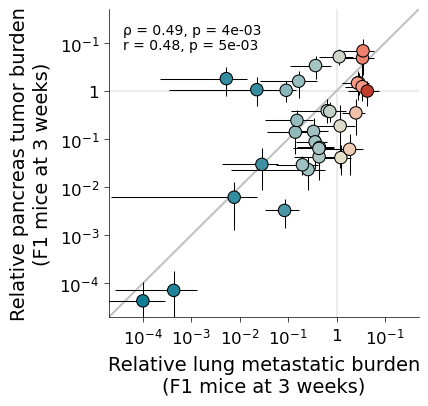

In [10]:
name = 'relative_exp_pancreas_vs_lung_exp2'
si = 'si'

excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs][::-1], clID__color=clID__color,
                                    clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                    clID__y=clID__in_vivo_exp_avg_pancreas_relative_to_mean, clID__yerr=clID__in_vivo_exp_pancreas_err,
                                    xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative pancreas tumor burden\n(F1 mice at 3 weeks)',
                                    lims=[2e-5, 0.5e2], ticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], labels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{-1}$'])

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

excluded: Spike-in 1
excluded: Panc02


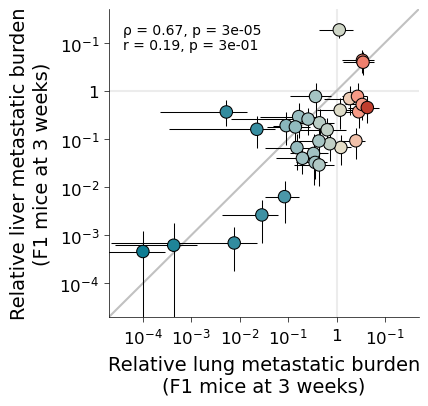

In [11]:
name = 'relative_exp_liver_vs_lung_exp2'
si = 'main'

excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs][::-1], clID__color=clID__color,
                                    clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                    clID__y=clID__in_vivo_exp_avg_liver_relative_to_mean, clID__yerr=clID__in_vivo_exp_liver_err,
                                    xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)',
                                    lims=[2e-5, 0.5e2], ticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], labels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{-1}$'])

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

excluded: Spike-in 1
excluded: Panc02


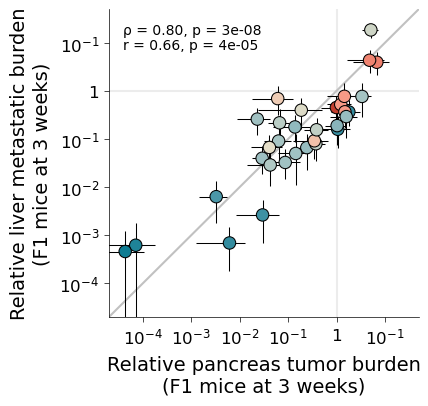

In [12]:
name = 'relative_exp_liver_vs_pancreas_exp2'
si = 'main'

#excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs], clID__color=clID__color,
                                    clID__x=clID__in_vivo_exp_avg_pancreas_relative_to_mean, clID__xerr=clID__in_vivo_exp_pancreas_err,
                                    clID__y=clID__in_vivo_exp_avg_liver_relative_to_mean, clID__yerr=clID__in_vivo_exp_liver_err,
                                    xtitle='Relative pancreas tumor burden\n(F1 mice at 3 weeks)', ytitle='Relative liver metastatic burden\n(F1 mice at 3 weeks)',
                                    lims=[2e-5, 0.5e2], ticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], labels=['$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{-1}$'])

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

excluded: Spike-in 1
excluded: Panc02


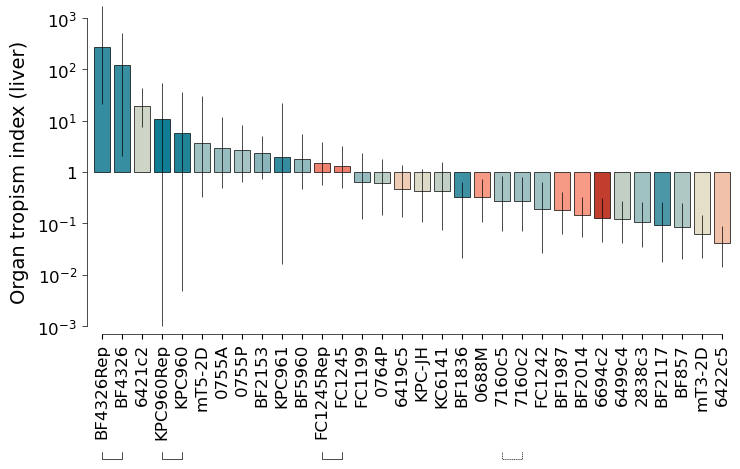

In [17]:
name = 'liver_tropism'
si = 'main'

#excluded_clIDs = ['GATC', 'AGCA', 'CAGA', 'GCAT', 'ATCG', 'CACT']
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])

# calculating organ tropism index: liver
clID__liver_index_distr = {}
clID__liver_index_mean = {}
clID__liver_index_err = {}
for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    clID__liver_index_distr[clID] = clID__in_vivo_exp_liver_relative_to_mean[clID] / (clID__in_vivo_exp_relative_to_mean[clID])
    
for clID in clIDs:
    if clID in excluded_clIDs:
        continue
    y = np.mean(clID__liver_index_distr[clID])
    clID__liver_index_mean[clID] = y
    
    ci_upper = np.percentile(clID__liver_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__liver_index_distr[clID], 2.5)
    clID__liver_index_err[clID] = [min(y - 1e-3, y - ci_lower), ci_upper - y]
    
clIDs_sorted = [y[0] for y in sorted([[x, clID__liver_index_mean[x]] for x in clIDs if x not in excluded_clIDs], key = lambda x: x[-1], reverse=True)]

ax = utils.metric_bar_plot(clIDs_sorted, clID__liver_index_mean, clID__liver_index_err, 
                           ytitle='Organ tropism index (liver)', clID__color=clID__color, ann=0.004,
                           ylims=[1e-3, 1e3], yticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3], ylabels=['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$', '$10^{3}$'])

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

## Correlation matrix and clustering

In [20]:
# making a matrix w/ all correlation coefficientst -- computing missing data

# making a list of 3w Rag1 iv lung samples from exp. two
what = ['2', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_wo_immune_system = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['injection method'] == what[3]) & 
                                   (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

(
    clID__in_vivo_exp_wo_immune_system, 
    clID__in_vivo_exp_wo_immune_system_relative_to_mean, 
    clID__in_vivo_exp_wo_immune_system_avg_relative_to_mean, 
    clID__in_vivo_exp_wo_immune_system_err, 
    clIDs_wo_immune_system_sorted
) = utils.bootstrap_relative_burden(
    samples_wo_immune_system, 
    read_counts=read_counts_by_cell_line, 
    cell_counts=cell_counts_by_cell_line, 
    metadata=metadata
)

# making a list of 3w F1 iv lung samples from exp. one
what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

(
    clID__in_vivo_exp_1, 
    clID__in_vivo_exp_relative_to_mean_1, 
    clID__in_vivo_exp_avg_relative_to_mean_1, 
    clID__in_vivo_exp_err_1, 
    clIDs_sorted_1
) = utils.bootstrap_relative_burden(
    samples, 
    read_counts=read_counts_by_cell_line, 
    cell_counts=cell_counts_by_cell_line, 
    metadata=metadata
)

# making a list of 3w Rag1 iv lung samples from exp. two
what = ['1', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_wo_immune_system = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['injection method'] == what[3]) & 
                                   (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

(
    clID__in_vivo_exp_wo_immune_system_1, 
    clID__in_vivo_exp_wo_immune_system_relative_to_mean_1, 
    clID__in_vivo_exp_wo_immune_system_avg_relative_to_mean_1, 
    clID__in_vivo_exp_wo_immune_system_err_1, 
    clIDs_wo_immune_system_sorted_1
) = utils.bootstrap_relative_burden(
    samples_wo_immune_system, 
    read_counts=read_counts_by_cell_line, 
    cell_counts=cell_counts_by_cell_line, 
    metadata=metadata
)

# in vitro data
in_vitro_samples = metadata[
    (metadata['experiment'] == 'in vitro') |
    ((metadata['time point, d'] == 0) & (metadata['experiment'] == '1'))
].groupby('time point, d')\
 .apply(lambda df: df.index.tolist(), include_groups=False)

clIDs_ordered_in_vitro = ['AGGT', 'AGCA', 'CTTC', 'AGTC', 'ATCG', 'GAAG', 'CACT', 'ACCT',
                          'CCTT', 'CATG', 'GGAA', 'ACAC', 'GTTG', 'AGAG', 'TTGG', 'TCCA',
                          'CTGT', 'TTCC', 'CAGA', 'GCAT', 'CGTA', 'GGTT', 'ACGA', 'AAGG',
                          'GTAC', 'CGAT', 'GCTA', 'CAAC', 'TGAC', 'ATGC', 'ACTG', 'GTGA',
                          'CCAA'] # clIDs sorted by weighted avg expansion in vitro

clID__in_vitro_exp = {}
clID__in_vitro_exp_err = {}
for clID in clIDs_ordered_in_vitro:
     
    t = 3 # normalizing by the fraction at t = 3 days 
    norm = np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in in_vitro_samples[t]])

    t = 23 # last time point
    y = [read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) / norm for sample_id in in_vitro_samples[t]]
    
    clID__in_vitro_exp[clID] = np.mean(y)
    clID__in_vitro_exp_err[clID] = [np.std(y), np.std(y)]



In [130]:
set(metadata['injection method'])

{'intrapancreatic', 'intraperitoneal', 'intrasplenic', 'intravenous', nan}

In [41]:
# making a matrix w/ all correlation coefficientst

# environments: in vitro, lung 3w f1 (1), lung 3w f1 rag1 (1), lung 3w f1 (2), lung 3w f1 rag1 (2), liver, panc
# make a matrix + cluster 

entities = [[clID__in_vitro_exp[x] for x in clIDs[1:]],
            [clID__in_vivo_exp_avg_relative_to_mean_1[x] for x in clIDs[1:]],
            [clID__in_vivo_exp_wo_immune_system_avg_relative_to_mean_1[x] for x in clIDs[1:]],
            [clID__in_vivo_exp_avg_relative_to_mean[x] for x in clIDs[1:]],
            [clID__in_vivo_exp_wo_immune_system_avg_relative_to_mean[x] for x in clIDs[1:]],
            [clID__in_vivo_exp_avg_liver_relative_to_mean[x] for x in clIDs[1:]],
            [clID__in_vivo_exp_avg_pancreas_relative_to_mean[x] for x in clIDs[1:]]]

labels = ['Relative in vitro expansion',
          'Relative lung metastatic burden\n[F1 mice at 3 weeks] Series 1',
          'Relative lung metastatic burden\n[Rag1-/- mice at 3 weeks] Series 1',
          'Relative lung metastatic burden\n[F1 mice at 3 weeks] Series 2',
          'Relative lung metastatic burden\n[Rag1-/- mice at 3 weeks] Series 2',
          'Relative liver metastatic burden',
          'Relative pancreas tumor burden']

n = len(entities)
corr_matrix_r = np.zeros((n, n))
corr_matrix_rho = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):  # compute only upper triangle
        r, _ = sp.stats.pearsonr(entities[i], entities[j])
        rho, _ = sp.stats.spearmanr(entities[i], entities[j])
        corr_matrix_r[i, j] = r
        corr_matrix_r[j, i] = r 
        corr_matrix_rho[i, j] = rho
        corr_matrix_rho[j, i] = rho

corr_matrix_r = pd.DataFrame(corr_matrix_r, index=labels, columns=labels)
corr_matrix_rho = pd.DataFrame(corr_matrix_rho, index=labels, columns=labels)


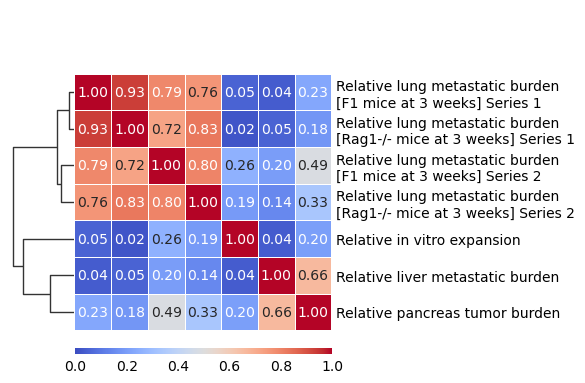

In [84]:
name = 'spearman_r_corr'
si = 'si'

ax = sns.clustermap(corr_matrix_r, cmap='coolwarm', norm=matplotlib.colors.Normalize(vmin=0, vmax=1), 
                    annot=True, fmt='.2f', linewidths=0.5,
                    figsize=(6, 6), dendrogram_ratio=(0.2, 0.2), 
                    cbar_pos=(0.134, 0.4, 0.428, 0.01), cbar_kws={'orientation': 'horizontal'})

ax.tick_params(axis='both', which='both', length=0) 
ax.ax_heatmap.set_xticklabels([]);
ax.ax_col_dendrogram.collections[0].set_linewidth(0)
ax.ax_row_dendrogram.collections[0].set_linewidth(1)

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

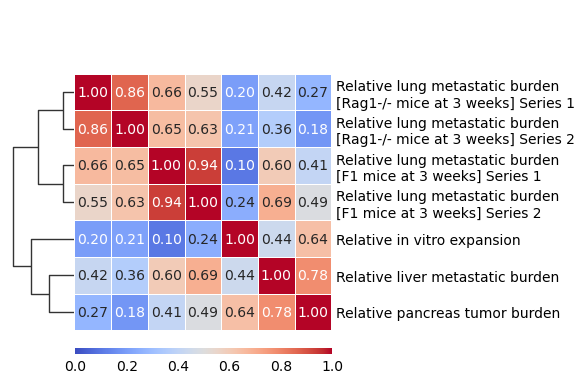

In [85]:
name = 'pearsons_rho_corr'
si = 'main'

ax = sns.clustermap(corr_matrix_rho, cmap='coolwarm', norm=matplotlib.colors.Normalize(vmin=0, vmax=1), 
                    annot=True, fmt='.2f', linewidths=0.5,
                    figsize=(6, 6), dendrogram_ratio=(0.2, 0.2), 
                    cbar_pos=(0.134, 0.4, 0.428, 0.01), cbar_kws={'orientation': 'horizontal'})

ax.tick_params(axis='both', which='both', length=0) 
ax.ax_heatmap.set_xticklabels([]);
ax.ax_col_dendrogram.collections[0].set_linewidth(0)
ax.ax_row_dendrogram.collections[0].set_linewidth(1)

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

### Supplementary figures: immune rejection plots

excluded: Spike-in 1
excluded: Panc02


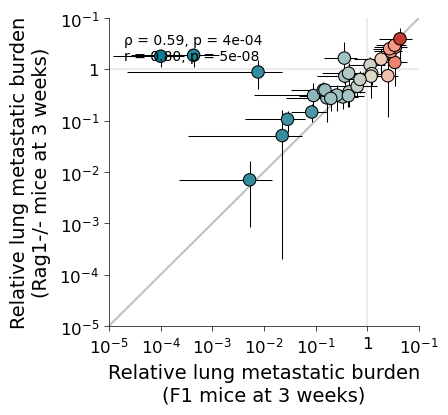

In [114]:
name = 'relative_in_vivo_exp_w_and_wo_immune_system_exp2'
si = 'si'

excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs][::-1], clID__color=clID__color,
                                   clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                   clID__y=clID__in_vivo_exp_wo_immune_system_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_wo_immune_system_err,
                                   xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks)',
                                   lims=[1e-5, 1e1], ticks=[1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], labels=['$10^{-5}$', '$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^{-1}$'])

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

In [115]:
# calculating immune rejection index
clID__immune_rejection_index_distr = {}
clID__immune_rejection_index_avg = {}
clID__immune_rejection_index_err = {}
for clID in clIDs:
    if clID in ['GATC', 'AGCA']:
        continue
    clID__immune_rejection_index_distr[clID] = clID__in_vivo_exp_wo_immune_system_relative_to_mean[clID] / clID__in_vivo_exp_relative_to_mean[clID]

for clID in clIDs:
    if clID in ['GATC', 'AGCA']:
        continue
    y = clID__in_vivo_exp_wo_immune_system_avg_relative_to_mean[clID] / clID__in_vivo_exp_avg_relative_to_mean[clID]
    clID__immune_rejection_index_avg[clID] = y
    
    ci_upper = np.percentile(clID__immune_rejection_index_distr[clID], 97.5)
    ci_lower = np.percentile(clID__immune_rejection_index_distr[clID], 2.5)
    clID__immune_rejection_index_err[clID] = [(y - ci_lower), (ci_upper - y)]
       
clIDs_sorted = [y[0] for y in sorted([[x, clID__immune_rejection_index_avg[x]] for x in clIDs if x not in ['GATC', 'AGCA']], key = lambda x: x[-1], reverse=True)]

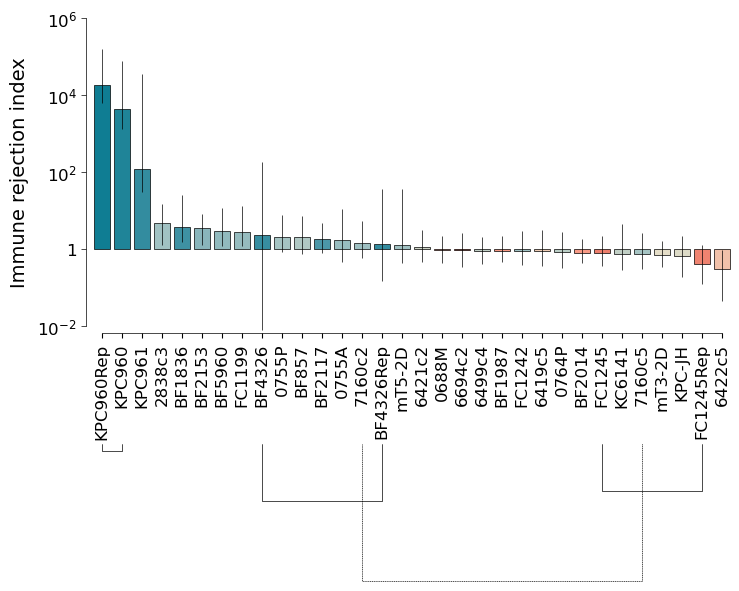

In [117]:
name = 'immune_rejection_index_exp2'
si = 'si'

ax = utils.metric_bar_plot(clIDs_sorted, clID__immune_rejection_index_avg, clID__immune_rejection_index_err, clID__color=clID__color,
                           ytitle='Immune rejection index', ann=0.001,
                           ylims=[1e-2, 1e6], yticks=[1e-2, 1e0, 1e2, 1e4, 1e6], ylabels=['$10^{-2}$', '$1$', '$10^{2}$', '$10^{4}$', '$10^{6}$'])

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


### Supplementary figures: in vitro comparisons

In [118]:
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [119]:
_, _, _, _, clIDs_sorted = utils.bootstrap_relative_burden(samples, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)


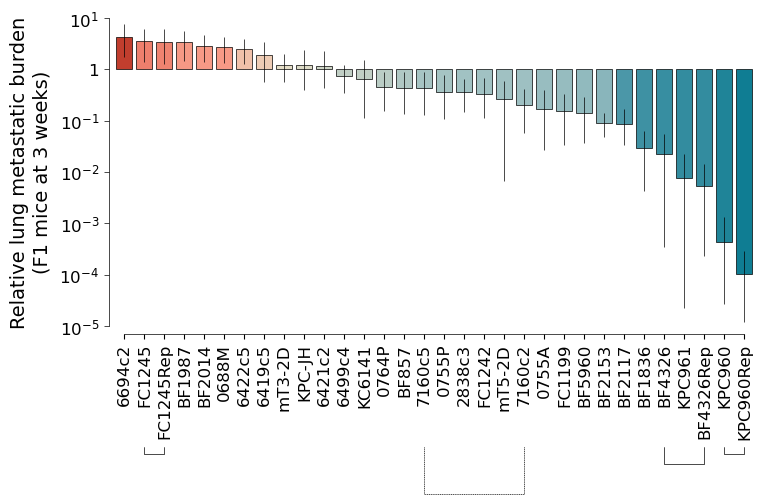

In [121]:
name = 'immune_rejection_index_exp2'
si = 'si'

ax = utils.metric_bar_plot(clIDs_sorted[:-1], clID__in_vivo_exp_avg_relative_to_mean, clID__in_vivo_exp_err, clID__color=clID__color,
                          ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ann=0.005,
                          ylims=[1e-5, 1e1], yticks=[1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1], ylabels=['$10^{-5}$', '$10^{-4}$', '$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '1', '$10^{1}$'])


plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


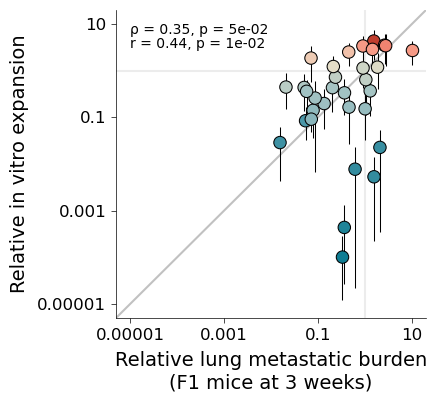

In [127]:
name = 'in_vitro_vs_f1_lung_exp2'
si = 'si'

ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']], clID__color=clID__color,
                                   clID__y=clID__in_vivo_exp_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_err,
                                   clID__x=clID__in_vitro_exp, clID__xerr=clID__in_vitro_exp_err,
                                   ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', xtitle='Relative in vitro expansion',
                                   lims=[5e-6, 0.2e2], ticks=[1e-5, 1e-3, 1e-1, 1e1], labels=['$10^{-5}$', '$10^{-3}$', '$10^{-1}$', ''])

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


In [ ]:
name = 'in_vitro_vs_rag1_lung_exp2'
si = 'si'

ax = utils.comparison_scatter_plot([x for x in clIDs if x not in ['GATC', 'AGCA']], clID__color=clID__color,
                                   clID__x=clID__in_vivo_exp_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_err,
                                   clID__y=clID__in_vitro_exp, clID__yerr=clID__in_vitro_exp_err,
                                   xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative in vitro expansion',
                                   lims=[5e-6, 0.2e2], ticks=[1e-5, 1e-3, 1e-1, 1e1], labels=['0.00001', '0.001', '0.1', '10'])

plt.savefig(path_to_save_figs + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    


### Experiment vs experiment comparisons

In [ ]:
# 3 week F1 mice:

what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, _, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = utils.bootstrap_relative_burden(samples_1, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_2, _, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = utils.bootstrap_relative_burden(samples_2, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)

In [ ]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                   clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                                   clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                                   xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks), exp. 1', ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks), exp. 2',
                                   lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

plt.savefig(path_to_save_figs + 'fig4_si_exp_1vs_2_3w_f1_iv_lung.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
# 3 week Rag1 mice:

what = ['1', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'Rag1-/-', 'intravenous', 'lung']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, _, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = utils.bootstrap_relative_burden(samples_1, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_2, _, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = utils.bootstrap_relative_burden(samples_2, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)

In [ ]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                   clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                                   clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                                   xtitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks), exp. 1', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks), exp. 2',
                                   lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

plt.savefig(path_to_save_figs + '/fig4_si_exp_1vs_2_3w_rag1_iv_lung.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'liver']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'C57B6/129S F1', 'intrasplenic', 'liver']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, _, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = utils.bootstrap_relative_burden(samples_1, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_2, _, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = utils.bootstrap_relative_burden(samples_2, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)

In [ ]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                    clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                                    clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                                    xtitle='Relative liver metastatic burden\n(intraperitoneal injection, exp. 1)', ytitle='Relative liver metastatic burden\n(intrasplenic injection, exp. 2)',
                                    lims=[5e-5, 2e2], ticks=[1e-4, 1e-2, 1e0, 1e2], labels=['0.0001', '0.01', '1', '100'])

plt.savefig(path_to_save_figs + 'fig4_si_exp_1vs_2_liver.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
what = ['1', 20, 'C57B6/129S F1', 'intraperitoneal', 'pancreas']
samples_1 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

what = ['2', 20, 'C57B6/129S F1', 'intrapancreatic', 'pancreas']
samples_2 = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                  (metadata['time point, d'] > what[1]) & # be careful here
                                  (metadata['genotype'] == what[2]) &
                                  (metadata['injection method'] == what[3]) & 
                                  (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__in_vivo_exp_1, _, clID__in_vivo_exp_1_avg_relative_to_mean, clID__in_vivo_exp_1_err, clIDs_sorted_1 = utils.bootstrap_relative_burden(samples_1, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)
clID__in_vivo_exp_2, _, clID__in_vivo_exp_2_avg_relative_to_mean, clID__in_vivo_exp_2_err, clIDs_sorted_2 = utils.bootstrap_relative_burden(samples_2, read_counts=read_counts_by_cell_line, cell_counts=cell_counts_by_cell_line, metadata=metadata)

In [ ]:
excluded_clIDs = ['GATC', 'AGCA']
for clID in excluded_clIDs:
    print('excluded: ' + clID__label[clID])
    
ax = utils.comparison_scatter_plot([x for x in clIDs if x not in excluded_clIDs],
                                    clID__x=clID__in_vivo_exp_1_avg_relative_to_mean, clID__xerr=clID__in_vivo_exp_1_err,
                                    clID__y=clID__in_vivo_exp_2_avg_relative_to_mean, clID__yerr=clID__in_vivo_exp_2_err,
                                    xtitle='Relative pancreas metastatic burden\n(intraperitoneal injection, exp. 1)', ytitle='Relative pancreas tumor burden\n(intrapancreatic injection, exp. 2)',
                                    lims=[1e-6, 1e2], ticks=[1e-6, 1e-4, 1e-2, 1e0, 1e2], labels=['0.000001', '0.0001', '0.01', '1', '100'])

plt.savefig(path_to_save_figs + 'fig4_si_exp_1vs_2_pancreas.pdf', dpi=300, bbox_inches='tight')  

### Rank order plot 

In [ ]:
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [ ]:
_, _, clID__in_vivo_exp_avg_relative_to_mean, _, clIDs_sorted = utils.bootstrap_relative_burden(samples, 
                                                                                                read_counts=read_counts_by_cell_line, 
                                                                                                cell_counts=cell_counts_by_cell_line, 
                                                                                                metadata=metadata)


In [ ]:
def sigmoid(xs, ys, smooth=8, n=100):
    """
    Interpolates a sigmoid function between x and y coordinates.
    
    Args:
        xs (array-like): Start and stop positions for the x-values.
        ys (array-like): Start and stop positions for the y-values.
        smooth (int, optional): Steepness of the sigmoid function's slope. Default is 8.
        n (int, optional): Number of interpolation points. Default is 100.

    Returns:
        tuple: Interpolated x and y values.
    """
    (x_from, x_to), (y_from, y_to) = xs, ys
    xs = np.linspace(-smooth, smooth, num=n)[:, None]
    ys = np.exp(xs) / (np.exp(xs) + 1)
    
    return ((ys * (x_to - x_from) + x_from), ((xs + smooth) / (smooth * 2) * (y_to - y_from) + y_from))



In [ ]:
# setting up:

data = [[i for i in range(len(clIDs_ordered_in_vitro))],
        [clIDs_sorted.index(i) for i in clIDs_ordered_in_vitro],
        [clIDs_sorted_liver.index(i) for i in clIDs_ordered_in_vitro],
        [clIDs_sorted_pancreas.index(i) for i in clIDs_ordered_in_vitro]]

n_js = len(clIDs_ordered_in_vitro)
n_environments = len(data)

fig, ax = plt.subplots(figsize=(6, 4))
ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)

highlight = ['ACCT', 'AGTC', 'CAAC', 'CTTC', 'GTTG', 'CATG', 'TCCA']
clID__z_order = {'ACCT': 6, 'AGTC': 5, 'CAAC': 7, 'CTTC': 4, 'GTTG': 8, 'CATG': 10, 'TCCA': 9}

# loop through each cell line and interpolate its rank transitions
for j in range(n_js):
    
    clID = clIDs_ordered_in_vitro[j]
    
    if clIDs_ordered_in_vitro[j] in highlight:
        c = clID__color[clID]
        z = clID__z_order[clID]
        l = 5
    else:
        c = tuple(0.15 * np.array(clID__color[clID]) + 0.85 * np.array([1, 1, 1, 1]))
        z = -1e3
        l = 3
    
    if clIDs_ordered_in_vitro[j] in ['TTGG', 'CAGA', 'GCAT']:
        c = '#d9d9d9'
        z = -len(highlight)
        C = 'black'
    elif clIDs_ordered_in_vitro[j] in ['ATCG', 'CACT']:
        c = '#898989'
        z = -len(highlight)
        C = 'black'
    else:
        C = clID__color[clIDs_ordered_in_vitro[j]]
    
    plt.scatter(data[0][j], 0, color=clID__color[clID], s=60, edgecolor='black', linewidth=0.5, zorder=1e3)
    plt.text(data[0][j], -0.2, clID__label[clID], rotation=90, fontsize=10, ha='center')
    
    for i in range(n_environments - 1):
        x_values = [data[i][j], data[i + 1][j]]  # rank positions
        y_values = [i, (i + 1)]  # environments
        
        # use sigmoid interpolation (environment on y-axis, rank on x-axis)
        interp_x, interp_y = sigmoid(x_values, y_values, smooth=8, n=100)

        # plot smooth transition (rank on x-axis, environment on y-axis)
        plt.plot(interp_x, interp_y, color=c, linewidth=l, zorder=z)
        plt.scatter(data[i + 1][j], i + 1, color=C, s=60, edgecolor='black', linewidth=0.5, zorder=1e3)


plt.text(34, 0, '$In$' + ' ' + '$vitro$' + '\nexpansion', va='center')
plt.text(34, 1, 'Lung\nmetastatic\nburden', va='center')
plt.text(34, 2, 'Liver\nmetastatic\nburden', va='center')
plt.text(34, 3, 'Pancreas\ntumor\nburden', va='center')

         
plt.gca().invert_yaxis()  # flip y-axis so first environment is at the top

plt.xticks([]);
plt.yticks([]);

ax.annotate('', xy=(2, -0.725), xycoords='data', xytext=(3, -0.725), textcoords='data',
            arrowprops=dict(arrowstyle='-', linewidth=0.5, color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(4, -0.725), xycoords='data', xytext=(6, -0.725), textcoords='data',
            arrowprops=dict(arrowstyle='-', linewidth=0.5, color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=0.2'), 
            annotation_clip=False);

ax.annotate('', xy=(18, -0.725), xycoords='data', xytext=(19, -0.725), textcoords='data',
            arrowprops=dict(arrowstyle='-', linewidth=0.5, color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=0.4'), 
            annotation_clip=False);

ax.annotate('', xy=(22, -0.725), xycoords='data', xytext=(23, -0.725), textcoords='data',
            arrowprops=dict(arrowstyle='-', linewidth=0.5, linestyle=':', color='0', patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=0.4'), 
            annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig4_rank_order_plot.pdf', dpi=300, bbox_inches='tight')  

### PCA plot

In [ ]:
# trying to do PCA 
data = pd.DataFrame({'lung': clID__in_vivo_exp_avg_relative_to_mean, 
                     'liver': clID__in_vivo_exp_avg_liver_relative_to_mean, 
                     'pancreas': clID__in_vivo_exp_avg_pancreas_relative_to_mean})

pca = PCA(n_components=3)
components = pca.fit_transform(StandardScaler().fit_transform(data))
components_dict = dict(zip(list(data.index), components))

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
var_explained = pca.explained_variance_ratio_

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.spines[['top', 'right']].set_visible(False)

c = 0
for count, i in enumerate(clIDs_ordered_in_vitro):

    plt.scatter(components_dict[i][c + 0], components_dict[i][c + 1], color=clID__color[i], s=80, edgecolor='black', linewidth=0.5, alpha=1)
    #plt.text(components_dict[i][c + 0], components_dict[i][c + 1], clID__label[i])
    
    plt.xticks([-5, 0, 5, 10], size=12);
    plt.yticks([-5, 0, 5], size=12);
    plt.xlim(-5, 10);
    plt.ylim(-5, 5);
        

plt.xlabel('Principle component #%.0f,\n%.2f variance explained' % (c + 1, var_explained[c + 0]), fontsize=12, labelpad=10);
plt.ylabel('Principle component #%.0f,\n%.2f variance explained' % (c + 2, var_explained[c + 1]), fontsize=12, labelpad=10);


plt.savefig(path_to_save_figs + 'fig4_pca.pdf', dpi=300, bbox_inches='tight')  

### Supplementary figures: tumor size distributions

In [ ]:
# making a list of 3w F1 iv lung samples from exp. one
what = ['2', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

print(len(samples))

In [ ]:
clID__percentiles, clID__ci, clID__cum_sum, clID__cum_sum_ci = utils.bootstrap_tumor_size_percentiles(samples,
                                                                                                      path_to_data=path_to_reads,
                                                                                                      percentiles=[50, 60, 70, 80, 90, 99],
                                                                                                      read_counts=read_counts_by_cell_line,
                                                                                                      metadata=metadata)

In [ ]:
_, _, _, _, clIDs_sorted = utils.bootstrap_relative_burden(samples, 
                                                        read_counts=read_counts_by_cell_line, 
                                                        cell_counts=cell_counts_by_cell_line, 
                                                        metadata=metadata)


In [ ]:
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted[:-1]):
    rgb = np.array(clID__color[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(clID__percentiles[clID]))
    for j, p in enumerate(clID__percentiles[clID]):
        plt.scatter(i + j * 0.1, clID__percentiles[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5)
        plt.errorbar(i + j * 0.1, clID__percentiles[clID][j],  [[clID__percentiles[clID][j] - clID__ci[clID][0][j]], [clID__ci[clID][1][j] - clID__percentiles[clID][j]]], color='black', linewidth=0.5, zorder=-1)
    if i % 2 == 0:
        plt.fill_between([i - 0.25, i + j * 0.1 + 0.25], 1e1, 1e7, color='#e9e9e9', zorder=-2)
        
# for legend:
gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(clID__percentiles[clID]))[::-1]
for j, p in enumerate([50, 60, 70, 80, 90, 99][::-1]):
    plt.scatter(-1, clID__percentiles[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5, label=p)
    
plt.yscale('log')
plt.minorticks_off()

plt.legend(frameon=False, bbox_to_anchor=(0.75, -0.5), ncol=len(gradient), handletextpad=0, columnspacing=0.1)

plt.ylim(1e1, 1e7)
plt.xlim(-0.25, i + j * 0.1 + 0.25)
plt.yticks(size=12)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='left', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Tumor size, cells', fontsize=14)

plt.savefig(path_to_save_figs + 'fig4_tumor_size_distr_lung.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
what = ['2', 20, 'C57B6/129S F1', 'pancreas']
samples_pancreas = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


what = ['2', 20, 'C57B6/129S F1', 'liver']
samples_liver = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                   (metadata['time point, d'] > what[1]) & # be careful here
                                   (metadata['genotype'] == what[2]) &
                                   (metadata['tissue'] == what[3])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts


In [ ]:
clID__percentiles_pancreas, clID__ci_pancreas, _, _ = utils.bootstrap_tumor_size_percentiles(samples_pancreas,
                                                                                       path_to_data=path_to_reads,
                                                                                       percentiles=[50, 60, 70, 80, 90, 99],
                                                                                       read_counts=read_counts_by_cell_line,
                                                                                       metadata=metadata)

In [ ]:
clID__percentiles_liver, clID__ci_liver, _, _ = utils.bootstrap_tumor_size_percentiles(samples_liver,
                                                                                 path_to_data=path_to_reads,
                                                                                 percentiles=[50, 60, 70, 80, 90, 99],
                                                                                 read_counts=read_counts_by_cell_line,
                                                                                 metadata=metadata)

In [ ]:
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted[:-1]):
    rgb = np.array(clID__color[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(clID__percentiles_pancreas[clID]))
    for j, p in enumerate(clID__percentiles_pancreas[clID]):
        plt.scatter(i + j * 0.1, clID__percentiles_pancreas[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5)
        plt.errorbar(i + j * 0.1, clID__percentiles_pancreas[clID][j],  [[clID__percentiles_pancreas[clID][j] - clID__ci_pancreas[clID][0][j]], [clID__ci_pancreas[clID][1][j] - clID__percentiles_pancreas[clID][j]]], color='black', linewidth=0.5, zorder=-1)
    if i % 2 == 0:
        plt.fill_between([i - 0.25, i + j * 0.1 + 0.25], 1e1, 1e7, color='#e9e9e9', zorder=-2)
        
# for legend:
gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(clID__percentiles_pancreas[clID]))[::-1]
for j, p in enumerate([50, 60, 70, 80, 90, 99][::-1]):
    plt.scatter(-1, clID__percentiles_pancreas[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5, label=p)
    
plt.yscale('log')
plt.minorticks_off()

plt.legend(frameon=False, bbox_to_anchor=(0.75, -0.5), ncol=len(gradient), handletextpad=0, columnspacing=0.1)

plt.ylim(1e1, 1e7)
plt.xlim(-0.25, i + j * 0.1 + 0.25)
plt.yticks(size=12)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='left', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Tumor size, cells', fontsize=14)

plt.savefig(path_to_save_figs + 'fig4_tumor_size_distr_pancreas.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(8, 2))
for i, clID in enumerate(clIDs_sorted[:-1]):
    rgb = np.array(clID__color[clID])
    white = np.array([1, 1, 1, 1])
    gradient = np.linspace(white, rgb, len(clID__percentiles_liver[clID]))
    for j, p in enumerate(clID__percentiles_liver[clID]):
        plt.scatter(i + j * 0.1, clID__percentiles_liver[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5)
        plt.errorbar(i + j * 0.1, clID__percentiles_liver[clID][j],  [[clID__percentiles_liver[clID][j] - clID__ci_liver[clID][0][j]], [clID__ci_liver[clID][1][j] - clID__percentiles_liver[clID][j]]], color='black', linewidth=0.5, zorder=-1)
    if i % 2 == 0:
        plt.fill_between([i - 0.25, i + j * 0.1 + 0.25], 1e1, 1e7, color='#e9e9e9', zorder=-2)
        
# for legend:
gradient = np.linspace(np.array([1, 1, 1, 1]), np.array([0.537, 0.537, 0.537, 1]), len(clID__percentiles_liver[clID]))[::-1]
for j, p in enumerate([50, 60, 70, 80, 90, 99][::-1]):
    plt.scatter(-1, clID__percentiles_liver[clID][j], color=gradient[j], edgecolor='black', linewidth=0.5, label=p)
    
plt.yscale('log')
plt.minorticks_off()

plt.legend(frameon=False, bbox_to_anchor=(0.75, -0.5), ncol=len(gradient), handletextpad=0, columnspacing=0.1)

plt.ylim(1e1, 1e7)
plt.xlim(-0.25, i + j * 0.1 + 0.25)
plt.yticks(size=12)

plt.xticks(range(0, len(clIDs_sorted[:-1])), [clID__label[clID] for clID in clIDs_sorted[:-1]], rotation=90, ha='left', size=12);
plt.gca().tick_params(axis='x', which='both', length=0)

plt.ylabel('Tumor size, cells', fontsize=14)

plt.savefig(path_to_save_figs + 'fig4_tumor_size_distr_liver.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
# want to plot cumulative burden distribution 
sample__clID__barcode__count = utils.convert_barcode_reads_to_cell_counts(samples, 
                                                                          path_to_data=path_to_reads, 
                                                                          read_counts=read_counts_by_cell_line, 
                                                                          metadata=metadata)
clID__tumor_sizes = {}
for i, clID in enumerate(clIDs[1:]):
    if clID not in clID__tumor_sizes:
        clID__tumor_sizes[clID] = []
    for sample in samples:
        clID__tumor_sizes[clID].extend([x for x in sample__clID__barcode__count[sample][clID].values()])


In [ ]:
plt.figure(figsize=(6, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    if clID not in ['ACCT', 'AGTC', 'ATCG', 'CAAC', 'CACT', 'CATG', 'CTTC', 'GTTG', 'TCCA', 'TTGG']:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 1 / (clIDs_sorted.index(clID) + 1)
        print(clID__label[clID])
                
    sorted_sizes = np.sort(tumor_sizes)
    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    plt.plot(sorted_sizes, cumulative_burden, marker='o', color=c, zorder=z)
    plt.scatter(sorted_sizes[-1], cumulative_burden[-1], color=c, zorder=z, clip_on=False)
    
plt.xscale('log')
plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.ylim(0, 1)
plt.xlim(1e2, 1e7)

plt.xlabel("Tumor size, cells", size=14)
plt.ylabel("Cumulative contribution\nto tumor burden", size=14)

plt.savefig(path_to_save_figs + 'fig4_cumulative_burden_exp_2_lung_highlights.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(3, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    
    sorted_sizes = np.sort(tumor_sizes)[::-1]

    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    
    if clID not in ['ACCT', 'AGTC', 'ATCG', 'CAAC', 'CACT', 'CATG', 'CTTC', 'GTTG', 'TCCA', 'TTGG']:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 1 / (clIDs_sorted.index(clID) + 1)
        print(clID__label[clID])

    plt.plot(range(1, len(sorted_sizes) + 1), cumulative_burden, color=c, marker='o', zorder=z, clip_on=False)
    #plt.scatter(1, cumulative_burden[0], color=c, zorder=z)
    #plt.scatter(len(sorted_sizes), 1, color=c, zorder=z, clip_on=False)
        
plt.xscale('log')
plt.yscale('log')
#plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.xlim(0.5e0, 1e4)
plt.ylim(1e-3, 1)

plt.ylabel("Cumulative burden", size=14)
plt.xlabel("Number of tumors\n(from largest downward)", size=14)

plt.savefig(path_to_save_figs + 'fig4_cumulative_burden_from_the_right_exp_2_lung_highlights.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
# want to plot cumulative burden distribution 
sample__clID__barcode__count = utils.convert_barcode_reads_to_cell_counts(samples_pancreas, 
                                                                          path_to_data=path_to_reads, 
                                                                          read_counts=read_counts_by_cell_line, 
                                                                          metadata=metadata)
clID__tumor_sizes = {}
for i, clID in enumerate(clIDs[1:]):
    if clID not in clID__tumor_sizes:
        clID__tumor_sizes[clID] = []
    for sample in samples_pancreas:
        clID__tumor_sizes[clID].extend([x for x in sample__clID__barcode__count[sample][clID].values()])


In [ ]:
plt.figure(figsize=(6, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    if clID not in ['ACCT', 'AGTC', 'ATCG', 'CAAC', 'CACT', 'CATG', 'CTTC', 'GTTG', 'TCCA', 'TTGG']:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 1 / (clIDs_sorted.index(clID) + 1)
        print(clID__label[clID])
                
    sorted_sizes = np.sort(tumor_sizes)
    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    plt.plot(sorted_sizes, cumulative_burden, marker='o', color=c, zorder=z)
    plt.scatter(sorted_sizes[-1], cumulative_burden[-1], color=c, zorder=z, clip_on=False)
    
plt.xscale('log')
plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.ylim(0, 1)
plt.xlim(1e2, 1e7)

plt.xlabel("Tumor size, cells", size=14)
plt.ylabel("Cumulative contribution\nto tumor burden", size=14)

plt.savefig(path_to_save_figs + 'fig4_cumulative_burden_exp_2_pancreas_highlights.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(3, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    
    sorted_sizes = np.sort(tumor_sizes)[::-1]

    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    
    if clID not in ['ACCT', 'AGTC', 'ATCG', 'CAAC', 'CACT', 'CATG', 'CTTC', 'GTTG', 'TCCA', 'TTGG']:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 1 / (clIDs_sorted.index(clID) + 1)
        print(clID__label[clID])

    plt.plot(range(1, len(sorted_sizes) + 1), cumulative_burden, color=c, marker='o', zorder=z, clip_on=False)
    #plt.scatter(1, cumulative_burden[0], color=c, zorder=z)
    #plt.scatter(len(sorted_sizes), 1, color=c, zorder=z, clip_on=False)
        
plt.xscale('log')
plt.yscale('log')
#plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.xlim(0.5e0, 1e4)
plt.ylim(1e-3, 1)

plt.ylabel("Cumulative burden", size=14)
plt.xlabel("Number of tumors\n(from largest downward)", size=14)

plt.savefig(path_to_save_figs + 'fig4_cumulative_burden_from_the_right_exp_2_pancreas_highlights.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
# want to plot cumulative burden distribution 
sample__clID__barcode__count = utils.convert_barcode_reads_to_cell_counts(samples_liver, 
                                                                          path_to_data=path_to_reads, 
                                                                          read_counts=read_counts_by_cell_line, 
                                                                          metadata=metadata)
clID__tumor_sizes = {}
for i, clID in enumerate(clIDs[1:]):
    if clID not in clID__tumor_sizes:
        clID__tumor_sizes[clID] = []
    for sample in samples_liver:
        clID__tumor_sizes[clID].extend([x for x in sample__clID__barcode__count[sample][clID].values()])


In [ ]:
plt.figure(figsize=(6, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    if clID not in ['ACCT', 'AGTC', 'ATCG', 'CAAC', 'CACT', 'CATG', 'CTTC', 'GTTG', 'TCCA', 'TTGG']:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 1 / (clIDs_sorted.index(clID) + 1)
        print(clID__label[clID])
                
    sorted_sizes = np.sort(tumor_sizes)
    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    plt.plot(sorted_sizes, cumulative_burden, marker='o', color=c, zorder=z)
    plt.scatter(sorted_sizes[-1], cumulative_burden[-1], color=c, zorder=z, clip_on=False)
    
plt.xscale('log')
plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.ylim(0, 1)
plt.xlim(1e2, 1e7)

plt.xlabel("Tumor size, cells", size=14)
plt.ylabel("Cumulative contribution\nto tumor burden", size=14)

plt.savefig(path_to_save_figs + 'fig4_cumulative_burden_exp_2_liver_highlights.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
plt.figure(figsize=(3, 4))
plt.gca().spines[['top', 'right']].set_visible(False)

for clID, tumor_sizes in clID__tumor_sizes.items():
    if clID in ['GATC', 'AGCA']:
        continue
    
    sorted_sizes = np.sort(tumor_sizes)[::-1]

    cumulative_burden = np.cumsum(sorted_sizes)
    cumulative_burden /= cumulative_burden[-1]
    
    if clID not in ['ACCT', 'AGTC', 'ATCG', 'CAAC', 'CACT', 'CATG', 'CTTC', 'GTTG', 'TCCA', 'TTGG']:
        c = '#e9e9e9'
        z = -1
    else:
        c = clID__color[clID]
        z = 1 / (clIDs_sorted.index(clID) + 1)
        print(clID__label[clID])

    plt.plot(range(1, len(sorted_sizes) + 1), cumulative_burden, color=c, marker='o', zorder=z, clip_on=False)
    #plt.scatter(1, cumulative_burden[0], color=c, zorder=z)
    #plt.scatter(len(sorted_sizes), 1, color=c, zorder=z, clip_on=False)
        
plt.xscale('log')
plt.yscale('log')
#plt.xticks(size=12); plt.yticks(size=12);
plt.minorticks_off()
plt.xlim(0.5e0, 1e4)
plt.ylim(1e-3, 1)

plt.ylabel("Cumulative burden", size=14)
plt.xlabel("Number of tumors\n(from largest downward)", size=14)

plt.savefig(path_to_save_figs + 'fig4_cumulative_burden_from_the_right_exp_2_liver_highlights.pdf', dpi=300, bbox_inches='tight')  

In [ ]:
clID__label